In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from statsmodels.iolib.summary2 import summary_col

DATA_PATH = "immigration_comments_labelled.csv"

df = pd.read_csv(DATA_PATH).rename(columns={"author": "user_id"})
df["text"] = df["text"].astype(str).str.strip()
df["video_id"] = df["video_id"].astype(str)
df["user_id"] = df["user_id"].astype(str)
df["comment_id"] = df["comment_id"].astype(str)
df["parent_id"] = df["parent_id"].astype("string")

stance_lookup = df.set_index("comment_id")["comment_stance"].to_dict()
df["parent_stance"] = df["parent_id"].map(stance_lookup)

camps = {"Anti-immigration", "Non-anti-immigration"}
both_in_camp = df["comment_stance"].isin(camps) & df["parent_stance"].isin(camps)

df["is_cross_camp"] = np.where(
    df["is_reply"] & both_in_camp,
    (df["comment_stance"] != df["parent_stance"]).astype(float),
    np.nan,
)


In [ ]:
MODEL_NAME = "unitary/unbiased-toxic-roberta"
BATCH_SIZE = 32
MAX_LENGTH = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

id2label = model.config.id2label
label_names = [id2label[i] for i in range(len(id2label))]

@torch.no_grad()
def score_batch(texts):
    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    ).to(device)
    return torch.sigmoid(model(**encoded).logits).cpu().numpy()

texts = df["text"].tolist()
batches = []

for start in tqdm(range(0, len(texts), BATCH_SIZE)):
    batches.append(score_batch(texts[start:start + BATCH_SIZE]))

scores = np.vstack(batches)
scores_df = pd.DataFrame(scores, columns=label_names, index=df.index)

df = pd.concat([df, scores_df], axis=1)
df["tone_score"] = df["toxicity"]


In [ ]:
analysis_df_strict = df[
    df["is_reply"] & df["is_cross_camp"].notna()
].copy()

analysis_df_strict["is_cross_camp"] = analysis_df_strict["is_cross_camp"].astype(int)
analysis_df_strict["video_id_code"] = pd.factorize(analysis_df_strict["video_id"])[0]
analysis_df_strict["user_id_code"] = pd.factorize(analysis_df_strict["user_id"])[0]

cluster_groups = analysis_df_strict[["video_id_code", "user_id_code"]]


In [27]:
formula_m1 = (
    "tone_score ~ is_cross_camp "
    "+ C(video_stance, Treatment(reference='Neutral'))"
)

formula_m2 = (
    "tone_score ~ is_cross_camp "
    "+ C(comment_stance, Treatment(reference='Non-anti-immigration')) "
    "+ C(video_stance, Treatment(reference='Neutral'))"
)

formula_m3 = (
    "tone_score ~ is_cross_camp * "
    "C(comment_stance, Treatment(reference='Non-anti-immigration')) "
    "+ C(video_stance, Treatment(reference='Neutral'))"
)

formula_m3_alt = (
    "tone_score ~ is_cross_camp * "
    "C(comment_stance, Treatment(reference='Anti-immigration')) "
    "+ C(video_stance, Treatment(reference='Neutral'))"
)

ols_model1_baseline = smf.ols(formula_m1, data=analysis_df_strict).fit(
    cov_type="cluster", cov_kwds={"groups": cluster_groups}
)
ols_model2_stance = smf.ols(formula_m2, data=analysis_df_strict).fit(
    cov_type="cluster", cov_kwds={"groups": cluster_groups}
)
ols_model3_interact = smf.ols(formula_m3, data=analysis_df_strict).fit(
    cov_type="cluster", cov_kwds={"groups": cluster_groups}
)
ols_model3_altref = smf.ols(formula_m3_alt, data=analysis_df_strict).fit(
    cov_type="cluster", cov_kwds={"groups": cluster_groups}
)

summary_col(
    [ols_model1_baseline, ols_model2_stance, ols_model3_interact],
    model_names=["Model 1\n(Baseline)", "Model 2\n(+Stance)", "Model 3\n(+Interact)"],
    stars=True,
    float_format="%.3f",
)


,Model 1,Model 2,Model 3
,(Baseline),(+Stance),(+Interact)
Intercept,0.150***,0.089***,0.073***
,(0.025),(0.024),(0.019)
"C(video_stance, Treatment(reference='Neutral'))[T.Right]",0.017,0.008,0.003
,(0.027),(0.027),(0.029)
is_cross_camp,-0.027***,0.022***,0.044**
,(0.009),(0.008),(0.021)
"C(comment_stance, Treatment(reference='Non-anti-immigration'))[T.Anti-immigration]",,0.074***,0.094***
,,(0.008),(0.019)
"is_cross_camp:C(comment_stance, Treatment(reference='Non-anti-immigration'))[T.Anti-immigration]",,,-0.040


In [28]:
desc_df = analysis_df_strict.copy()
desc_df["comment_stance_anti"] = (
    desc_df["comment_stance"] == "Anti-immigration"
).astype(int)
desc_df["video_stance_right"] = (
    desc_df["video_stance"] == "Right"
).astype(int)

desc_vars = [
    "tone_score",
    "is_cross_camp",
    "comment_stance_anti",
    "video_stance_right",
]

desc_stats_raw = pd.DataFrame({
    "N": desc_df[desc_vars].count().astype(int),
    "Mean": desc_df[desc_vars].mean(),
    "SD": desc_df[desc_vars].std(),
    "Min": desc_df[desc_vars].min(),
    "Max": desc_df[desc_vars].max(),
})

print(f"===== Table 4 变量描述性统计 (N = {len(desc_df)}) =====")
print(desc_stats_raw.round(3))
print("\nsaved: TableE1_table4_descriptive_statistics.docx")


===== Table 4 变量描述性统计 (N = 10961) =====
                         N   Mean     SD  Min    Max
tone_score           10961  0.154  0.298  0.0  0.999
is_cross_camp        10961  0.265  0.442  0.0  1.000
comment_stance_anti  10961  0.743  0.437  0.0  1.000
video_stance_right   10961  0.679  0.467  0.0  1.000

saved: TableE1_table4_descriptive_statistics.docx


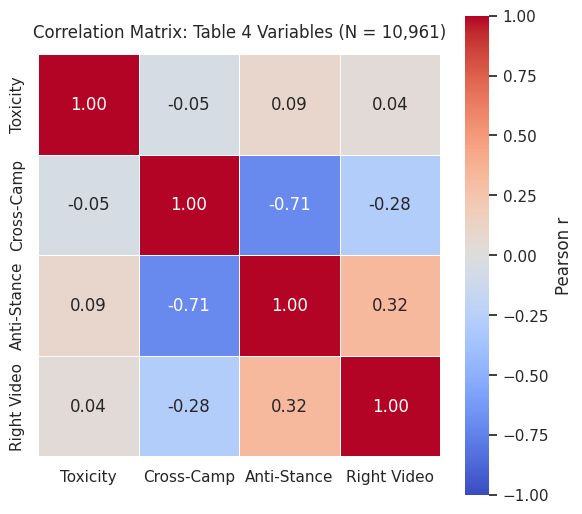

saved: FigureE1_correlation_heatmap_table4.png


In [29]:
heatmap_labels = {
    "tone_score": "Toxicity",
    "is_cross_camp": "Cross-Camp",
    "comment_stance_anti": "Anti-Stance",
    "video_stance_right": "Right Video",
}

corr = (
    desc_df[desc_vars]
    .corr()
    .rename(index=heatmap_labels, columns=heatmap_labels)
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.85},
    ax=ax,
)

ax.set_title(
    "Correlation Matrix: Table 4 Variables (N = 10,961)",
    fontsize=12,
    pad=12,
)

plt.tight_layout()
plt.savefig("FigureE1_correlation_heatmap_table4.png", dpi=300, bbox_inches="tight")
plt.show()

print("saved: FigureE1_correlation_heatmap_table4.png")


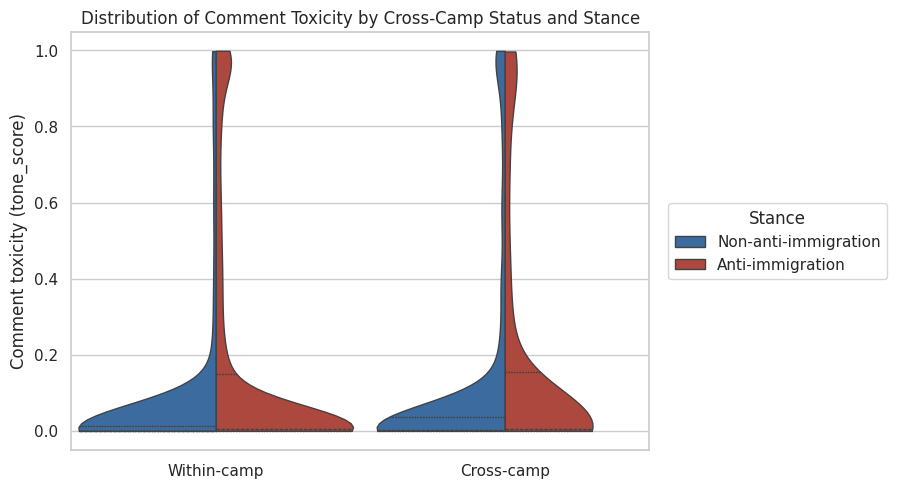

In [32]:
plot_df = analysis_df_strict.copy()
plot_df["Cross-camp status"] = plot_df["is_cross_camp"].map({
    0: "Within-camp",
    1: "Cross-camp",
})

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.violinplot(
    data=plot_df,
    x="Cross-camp status",
    y="tone_score",
    hue="comment_stance",
    order=["Within-camp", "Cross-camp"],
    hue_order=["Non-anti-immigration", "Anti-immigration"],
    split=True,
    inner="quartile",
    cut=0,
    width=0.95,
    bw_adjust=1.1,
    linewidth=1,
    palette={
        "Non-anti-immigration": "#2b6cb0",
        "Anti-immigration": "#c0392b",
    },
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Comment toxicity (tone_score)")
ax.set_title("Distribution of Comment Toxicity by Cross-Camp Status and Stance")
ax.legend(
    title="Stance",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)

plt.subplots_adjust(left=0.10, right=0.78, bottom=0.14, top=0.90)
plt.savefig("figC_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
